# 18 — how close is too close

Notebook 17 asked when sorting works as the molecules move faster. This one
holds them still — the friendliest case there is — and brings the two states
together until each method stops separating them.

Three methods, three answers, and they are not the same:

1. can you **see** two spots in the diagram?
2. does **clustering** find two groups?
3. do the two **sub-ensemble fits** return distances that are apart by more than
   their own uncertainties?

The third is the only one of the three that is a measurement, and it is the one
this notebook reports. It is also deliberately a statement about the two
*answers* rather than about the truth: on a real sample the truth is not
available, and a criterion that needs it is not a criterion.

Notebook 05 measured the same limit for the **pooled** analysis — two
populations resolved from a separation of 0.30 in $R/R_0$ inside the window and
never at 0.15. The question here is whether sorting buys anything.


In [1]:
import time, collections
import numpy as np
import matplotlib.pyplot as plt
import single_molecule as SM
from bd import P


In [2]:
st = P.default_settings()
st['n_bursts'] = 6000
model = P.build_model(st)
rel = model['rel']
SEPARATIONS = [0.45, 0.30, 0.20, 0.15, 0.10]
CENTRE = 1.00
print(f'{"separation":>11}   the two states')
pairs = {}
for d in SEPARATIONS:
    p, (a, b) = SM.two_state_truth(model, CENTRE - d / 2, CENTRE + d / 2, f1=0.5)
    pairs[d] = (p, a, b)
    print(f'{d:>11.2f}   R/R0 {rel[a]:.3f} and {rel[b]:.3f}')


  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
 separation   the two states
       0.45   R/R0 0.772 and 1.228
       0.30   R/R0 0.852 and 1.148
       0.20   R/R0 0.899 and 1.102
       0.15   R/R0 0.925 and 1.072
       0.10   R/R0 0.950 and 1.049


## The diagrams

No exchange at all: every molecule stays in one state for the whole burst, so
every burst must sit on the static line. What changes from panel to panel is
only how far apart the two spots are.


In [3]:
runs = {}
for d in SEPARATIONS:
    p, a, b = pairs[d]
    tab = P.physics_tables(model, st, p, verbose=False)
    s = SM.exchange_stream(model, st, tab, ((a, 0.5), (b, 0.5)), np.inf,
                           np.random.default_rng(5))
    tttr, sel, bursts, feat = SM.observables(model, st, s)
    runs[d] = dict(tab=tab, stream=s, tttr=tttr, bursts=bursts, feat=feat, j=(a, b))
    print(f'separation {d:.2f}: {len(feat)} bursts')


separation 0.45: 5511 bursts


separation 0.30: 5489 bursts


separation 0.20: 5441 bursts


separation 0.15: 5482 bursts


separation 0.10: 5494 bursts


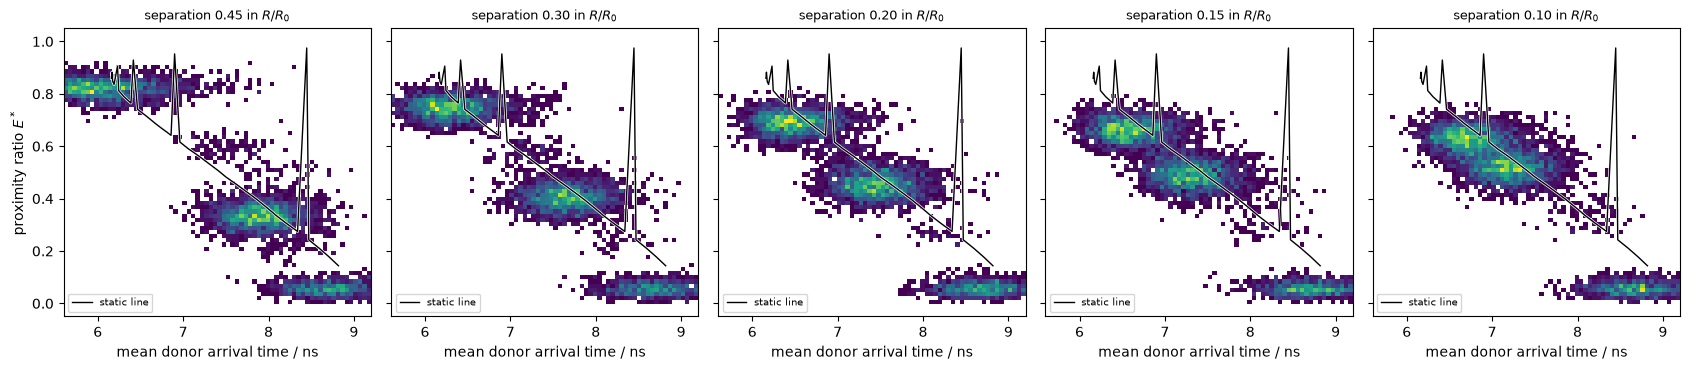

In [4]:
lt = SM.line_table(model, st, stride=4,
                   extra=tuple(j for d in SEPARATIONS for j in pairs[d][1:]))
line, _ = SM.static_line(model, lt)
fig, axes = plt.subplots(1, len(SEPARATIONS), figsize=(3.4 * len(SEPARATIONS), 3.8), sharey=True)
for ax, d in zip(axes, SEPARATIONS):
    SM.plot_e_tau(runs[d]['feat'], model, lt, ax=ax,
                  title=f'separation {d:.2f} in $R/R_0$', tau_range=(5.6, 9.2))
    if ax is not axes[0]:
        ax.set_ylabel('')
fig.tight_layout(); plt.show()


## Clustering

HDBSCAN on the two rulers. The donor-only bursts form their own group, so the
count to watch is the number of groups that are **not** the donor-only one.


In [5]:
seg = {}
for d in SEPARATIONS:
    labels = SM.segment(runs[d]['feat'])
    seg[d] = labels
    c = collections.Counter(labels)
    groups = sorted((g for g in c if g >= 0), key=lambda g: -c[g])
    #: the donor-only cluster is the one whose stoichiometry says the acceptor
    #: is missing, which the second laser tells us directly
    feat = runs[d]['feat']
    fret = [g for g in groups if np.nanmedian(feat[labels == g, 1]) < 0.85]
    seg[(d, 'fret')] = fret
    n_un = c.get(-1, 0)
    print(f'separation {d:.2f}: {len(groups)} groups, {len(fret)} with an acceptor '
          + ', '.join(f'#{g} ({c[g]})' for g in fret)
          + f';  {n_un} of {len(labels)} bursts unassigned ({n_un / len(labels):.0%})')


separation 0.45: 3 groups, 2 with an acceptor #1 (2137), #0 (2097);  284 of 5511 bursts unassigned (5%)
separation 0.30: 3 groups, 2 with an acceptor #1 (2175), #2 (2070);  233 of 5489 bursts unassigned (4%)
separation 0.20: 3 groups, 2 with an acceptor #1 (1958), #2 (1899);  532 of 5441 bursts unassigned (10%)
separation 0.15: 3 groups, 2 with an acceptor #1 (1630), #2 (1518);  1250 of 5482 bursts unassigned (23%)
separation 0.10: 3 groups, 2 with an acceptor #1 (1025), #2 (821);  2543 of 5494 bursts unassigned (46%)


## The fits

For each separation, the two largest acceptor-bearing groups are fitted, and
the whole labelled sample is fitted too — which is the pooled analysis notebooks
12 to 15 do. The comparison between the two is the question this notebook asks.

Every fit carries its Poisson deviance per degree of freedom against a measured
reference, and any fit that fails it is excluded and counted.


In [6]:
y_d0 = SM.donor_only_reference(model, st, runs[SEPARATIONS[0]]['tab'])
res = {}
t0 = time.time()
for d in SEPARATIONS:
    labels = seg[d]; fret = seg[(d, 'fret')][:2]
    for g in fret:
        sel = SM.group_photons(runs[d]['bursts'], labels, g)
        res[(d, f'group {g}')] = SM.group_fit(model, st, runs[d]['tttr'], sel, y_d0)
    #: and the pooled analysis: every burst, no sorting at all
    all_sel = np.concatenate([np.arange(a, b + 1) for a, b in runs[d]['bursts']])
    res[(d, 'pooled')] = SM.group_fit(model, st, runs[d]['tttr'], all_sel, y_d0)
    print(f'separation {d:.2f} done ({time.time() - t0:.0f} s so far)')


/Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/s88_laplace_posterior.py:2933: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:823.)
  evid = -float(f2) + 0.5 * graph.dim * math.log(2 * math.pi) - 0.5 * logdet


/Users/tpeulen/mambaforge/envs/arm64/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


separation 0.45 done (88 s so far)


separation 0.30 done (165 s so far)


separation 0.20 done (261 s so far)


separation 0.15 done (378 s so far)


separation 0.10 done (508 s so far)


In [7]:
print(f'{"sep":>5}{"what":>10}{"photons":>11}{"mean R/R0":>11}{"+-":>8}{"width":>8}'
      f'{"D/dof":>8}{"z":>7}   verdict')
for (d, what), r in res.items():
    v = 'quotable' if abs(r['z']) < 3 else 'EXCLUDED'
    print(f'{d:>5.2f}{what:>10}{r["photons"]:>11,.0f}{r["mean_rel"]:>11.3f}'
          f'{r["mean_sd"]:>8.3f}{r["width_rel"]:>8.3f}{r["dpd"]:>8.3f}{r["z"]:>7.1f}   {v}')


  sep      what    photons  mean R/R0      +-   width   D/dof      z   verdict
 0.45   group 1    425,106      1.213   0.014   0.069   1.092    0.1   quotable
 0.45   group 0    462,715      0.771   0.001   0.024   1.108    0.5   quotable
 0.45    pooled  1,086,756      1.003   0.029   0.234   1.078   -0.2   quotable
 0.30   group 1    451,471      1.134   0.013   0.103   1.069   -0.6   quotable
 0.30   group 2    447,331      0.850   0.001   0.020   1.069   -0.6   quotable
 0.30    pooled  1,085,461      1.030   0.044   0.219   1.053   -1.1   quotable
 0.20   group 1    410,584      1.092   0.007   0.058   1.101    0.1   quotable
 0.20   group 2    409,490      0.896   0.001   0.020   1.142    1.5   quotable
 0.20    pooled  1,073,425      1.004   0.015   0.130   1.110    0.5   quotable
 0.15   group 1    352,283      0.923   0.002   0.015   1.127    1.0   quotable
 0.15   group 2    316,846      1.063   0.004   0.028   1.077   -0.4   quotable
 0.15    pooled  1,076,293      0.993   0

## Are the two groups separated?

The criterion is on the answers: two recovered distances are separated when they
differ by more than twice the two uncertainties added in quadrature.


In [8]:
print(f'{"separation":>11}{"truth apart":>13}{"recovered apart":>17}{"uncertainty":>13}'
      f'{"ratio":>8}   separated?')
for d in SEPARATIONS:
    got = [r for (dd, w), r in res.items() if dd == d and w.startswith('group')]
    if len(got) < 2:
        print(f'{d:>11.2f}{d:>13.2f}{"-- only one group found --":>17}')
        continue
    q = SM.resolved(got[0], got[1])
    print(f'{d:>11.2f}{d:>13.2f}{q["separation"]:>17.3f}{q["uncertainty"]:>13.3f}'
          f'{q["ratio"]:>8.1f}   {"yes" if q["resolved"] else "NO"}')


 separation  truth apart  recovered apart  uncertainty   ratio   separated?
       0.45         0.45            0.442        0.014    30.7   yes
       0.30         0.30            0.284        0.013    22.2   yes
       0.20         0.20            0.196        0.008    25.7   yes
       0.15         0.15            0.140        0.005    30.2   yes
       0.10         0.10            0.093        0.005    20.1   yes


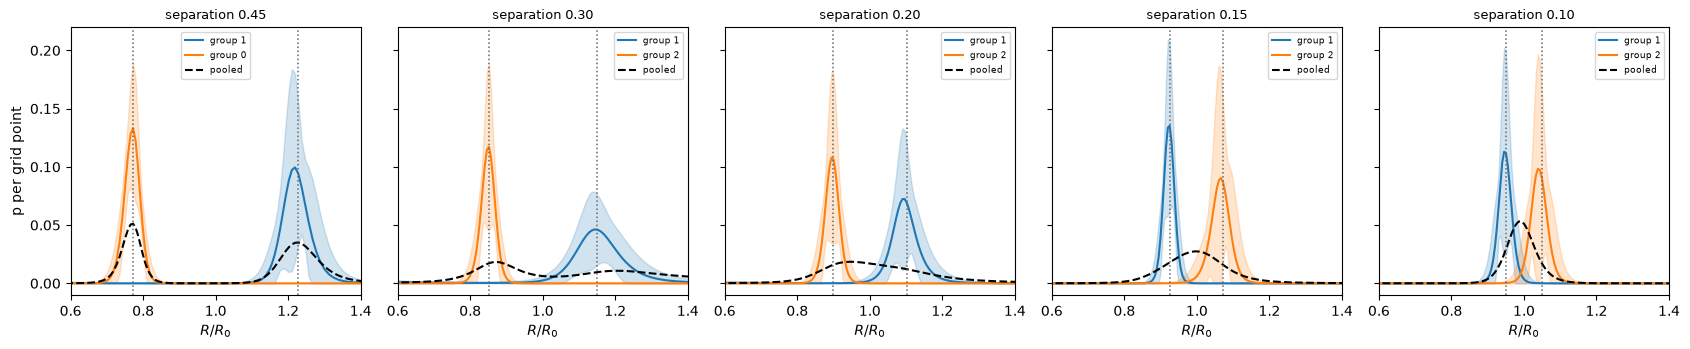

In [9]:
P._inline()
fig, axes = plt.subplots(1, len(SEPARATIONS), figsize=(3.4 * len(SEPARATIONS), 3.6), sharey=True)
for ax, d in zip(axes, SEPARATIONS):
    a, b = runs[d]['j']
    got = [(w, r) for (dd, w), r in res.items() if dd == d]
    for i, (w, r) in enumerate(got):
        c = 'k' if w == 'pooled' else f'C{i}'
        ls = '--' if w == 'pooled' else '-'
        ax.plot(rel, r['p_mean'], color=c, ls=ls, lw=1.5, label=w)
        if w != 'pooled':
            ax.fill_between(rel, r['p_lo'], r['p_hi'], alpha=0.2, color=c)
    ax.axvline(rel[a], color='0.4', ls=':', lw=1.1); ax.axvline(rel[b], color='0.4', ls=':', lw=1.1)
    ax.set_xlim(0.6, 1.4); ax.set_xlabel('$R/R_0$')
    ax.set_title(f'separation {d:.2f}', fontsize=9); ax.legend(fontsize=6.5)
axes[0].set_ylabel('p per grid point')
fig.tight_layout(); plt.show()


## The control: a sample with nothing to find

Everything above selects bursts by their transfer efficiency and their arrival
time, and then fits each selection. That is circular unless it can be shown that
the selection does not *manufacture* the structure it then reports — a
clustering that cuts any cloud in two will always hand back two groups at
different distances, and they will always look separated.

So: one state, no exchange, the same brightness, the same pipeline. If the
clustering splits it, nothing above means anything.

In [10]:
j0 = int(np.argmin(np.abs(rel - 1.00)))
p0 = np.zeros_like(rel); p0[j0] = 1.0
tab0 = P.physics_tables(model, st, p0, verbose=False)
s0 = SM.exchange_stream(model, st, tab0, ((j0, 1.0), (j0, 0.0)), np.inf,
                        np.random.default_rng(5))
tttr0, sel0, bursts0, feat0 = SM.observables(model, st, s0)
labels0 = SM.segment(feat0)
c0 = collections.Counter(labels0)
groups0 = sorted((g for g in c0 if g >= 0), key=lambda g: -c0[g])
fret0 = [g for g in groups0 if np.nanmedian(feat0[labels0 == g, 1]) < 0.85]
print(f'one state at R/R0 {rel[j0]:.3f}: {len(feat0)} bursts, {len(groups0)} groups, '
      f'{len(fret0)} with an acceptor: ' + ', '.join(f'#{g} ({c0[g]})' for g in fret0))
for g in fret0[:2]:
    r0 = SM.group_fit(model, st, tttr0, SM.group_photons(bursts0, labels0, g), y_d0)
    print(f'  group {g}: {r0["photons"]:>9,.0f} photons, '
          f'mean R/R0 {r0["mean_rel"]:.3f} +- {r0["mean_sd"]:.3f}, '
          f'D/dof {r0["dpd"]:.3f} (z {r0["z"]:+.1f})')
print('\nthe clustering found ' + ('ONE acceptor-bearing group, as it should'
      if len(fret0) == 1 else f'{len(fret0)} groups where there is one state -- '
      'everything above is a selection artefact'))

one state at R/R0 1.001: 5512 bursts, 2 groups, 1 with an acceptor: #1 (4399)


  group 1:   941,979 photons, mean R/R0 1.001 +- 0.002, D/dof 1.058 (z -0.9)

the clustering found ONE acceptor-bearing group, as it should


## What this establishes

**The control passes.** One state gives ONE acceptor-bearing group, fitted at
$R/R_0 = 1.001 \pm 0.002$ against a truth of 1.001. The clustering does not
split a single population of this brightness into two, so finding two groups is
evidence of two states rather than an artefact of having looked for them. Every
number below depends on that.

| separation | recovered apart | uncertainty | ratio | bursts unassigned | pooled fit |
|---|---|---|---|---|---|
| 0.45 | 0.442 | 0.014 | 31 | 5 % | one mean at 1.003, width 0.234 |
| 0.30 | 0.284 | 0.013 | 22 | 4 % | 1.030, width 0.219 |
| 0.20 | 0.196 | 0.008 | 26 | 10 % | 1.004, width 0.130 |
| 0.15 | 0.140 | 0.005 | 30 | 23 % | 0.993, width 0.085 |
| 0.10 | 0.093 | 0.005 | 20 | 46 % | 0.992, width 0.043 |

**Sorting separated the two states at every separation tried, down to 0.10 in
$R/R_0$.** The recovered separation is 2 to 7 per cent short of the truth, a pull
towards the middle that grows as the states approach. All fifteen fits are
quotable on their own statistic.

**The fair comparison is the last column**, because it is the same photons, the
same truth and the same seed. The pooled analysis returns a single mean near
1.00 throughout, with a width that shrinks from 0.234 to 0.043 as the two states
close — that is one population getting narrower, not two being resolved into two
reported distances. Sorting gives two distances where pooling gives one.

**What it costs is the fifth column.** At a separation of 0.10 the clustering
leaves 46 per cent of the bursts unassigned: the answer comes from the flanks of
a merged cloud and the photons in the middle are discarded. That is why the two
groups hold 224k and 174k photons where the pooled fit has 1.07M. A method that
throws away half the data is not free, even when the half it keeps is right.

## What it does not establish

**Not a resolution limit.** One truth, one photon budget, one seed. This is
where *this* measurement separated *these* two states, and the sweep stopped at
0.10 because that was the smallest separation tried — not because anything
failed. Treating a single-realisation boundary as a property of the method is
the mistake this series keeps finding in its own past work.

**Not a clean win over notebook 05.** That notebook's resolution test found two
populations resolved from a separation of 0.30 always, 0.20 sometimes and 0.15
never — but on populations of width 0.06 in $R/R_0$, over three realisations per
cell, at $10^6$ photons. The states here are single grid points with no width at
all, which is an easier problem. The two numbers are not measuring the same
thing, and the comparison inside this notebook, against its own pooled fits, is
the one to trust.

**The states here are static.** Notebook 17 showed what exchange does to
sorting. The interesting region is states that are close together *and*
exchanging, where both notebooks' failure modes meet, and neither has been
there.
